In [17]:
### Imports
from time import thread_time_ns
import numpy as np
from pathlib import Path
import random
import itertools
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np
import json
import math
import pprint
import pandas as pd
from time import thread_time_ns
from datetime import datetime
import statistics
from collections import defaultdict
import colorsys
from dataclasses import dataclass
from itertools import combinations
from math import hypot
import math
from PIL import Image


In [ ]:
def rgb_to_luv(rgb):
        rgb = np.array([rgb[0], rgb[1], rgb[2]],dtype=np.uint8) # yellow
        rgb = rgb.reshape((1,1,3))
        luv = cv.cvtColor(rgb,cv.COLOR_RGB2Luv)[:,0][0]
        return (int(luv[0]), int(luv[1]), int(luv[2])) if(type(rgb)==tuple) else luv


def rgb_to_cmyk(rgb):
    k = 1 - (max(rgb)/255)
    c = (1 - (rgb[0]/255)-k)/(1-k)
    m = (1 - (rgb[1]/255)-k)/(1-k)
    y = (1 - (rgb[2]/255)-k)/(1-k)
    return (round(c,3),round(m,3),round(y,3),round(k,3)) if type(rgb)==tuple else [round(c,3),round(m,3),round(y,3),round(k,3)]


def cmyk_to_rgb(cmyk):
     r= 255 * (1- cmyk[0]) * (1- cmyk[3])
     g= 255 * (1- cmyk[1]) * (1- cmyk[3])
     b= 255 * (1- cmyk[2]) * (1- cmyk[3])
     return [int(round(r,0)),int(round(g,0)),int(round(b,0))]

def cmyk_to_hsv(cmyk):
    rgb = cmyk_to_rgb(cmyk)
    return colorsys.rgb_to_hsv(rgb[0]/255, rgb[1]/255,rgb[2]/255)





(0.005376344086021519, 0.7673267326732673, 0.792156862745098)


In [6]:
def angle_to(p, q):
    """Angle in radians from p to q, clockwise from horizontal right."""
    if p == q:
        raise ValueError("no angle from a point to itself")
    
    px, py = p
    qx, qy = q

    dx = qx - px
    dy = qy - py

    angle = math.atan(dy/dx)

    if dx < 0:
        angle += math.pi

    return angle


def clockwisePoint(points, black):
    """The point that is the one clockwise from black, in the square formed by points."""
    other_corners = [pt for pt in points if pt != black]
    dists_to_corners = [math.dist(black, q) for q in other_corners]
    furthest = max(dists_to_corners)
    opposite_corner = other_corners[dists_to_corners.index(furthest)]

    adjacent_corners = [pt for pt in other_corners if pt != opposite_corner]
    angles_to_corners = [angle_to(black, q) for q in adjacent_corners]

    angle_range = max(angles_to_corners) - min(angles_to_corners)

    if angle_range < math.pi:
        # should be about pi/2
        clockwise_angle = min(angles_to_corners)
    else:
        # should be about 3/2 pi
        clockwise_angle = max(angles_to_corners)

    clockwise_pt = adjacent_corners[angles_to_corners.index(clockwise_angle)]
    return clockwise_pt

Find the centers - our current pipeline

In [7]:
def detection(thresholds,blob_params, gray):
    detector = cv.SimpleBlobDetector_create(blob_params)
    centers= []
    for thresh in thresholds:
        _, thresholded = cv.threshold(gray, thresh, 255, cv.THRESH_BINARY)
        keypoints = detector.detect(thresholded)
        current_centers = [(round(kp.pt[0]), round(kp.pt[1])) for kp in keypoints]
        new_centers = []
        for curr_center in current_centers:
            isNew = True
            for c in centers:
                    distance = math.dist(curr_center, c)
                    isNew = distance >= 10
                    if not isNew:
                        break
            if isNew:
                new_centers.append(curr_center)
        centers = centers + new_centers
    return centers


def blobParamFunc(minArea, minCircularity):
    params = cv.SimpleBlobDetector_Params()
    params.filterByCircularity = True
    params.minCircularity = minCircularity
    params.minArea=minArea
    params.blobColor = 0
    return params

def findCenters(file_path):
    image = cv.imread(file_path, cv.IMREAD_COLOR_RGB)
    imageBlurred = cv.medianBlur(image, 3)
    gray = cv.cvtColor(imageBlurred, cv.COLOR_RGBA2GRAY)
    thresholds = np.arange(150,200,10)
    blob_params = blobParamFunc(400, .8)
    point_list = detection(thresholds=thresholds, blob_params= blob_params, gray=gray)
    return (point_list,image)
     

Find the pixels around the center, block of 2xside by 2xside around that center, so side up and side down etc
side = 25, block of 50 by 50.
Return a list of pairs of the block and the x and y that it's around

Get the colors at each coordinate, and color correct them against the white that is in the corners of the image.

Clamp Function based on the Paper Programs clamping.

In [8]:
def clamp(value, lowerbound, upperbound):
    if value < lowerbound:
        return lowerbound
    elif value > upperbound:
        return upperbound
    return value

In [ ]:
def get_colors_and_coords(point_list, side, image, color_space):
    def getDotList(point_list, side, image):
        dot_list = []
        for pt in point_list:
            x,y= pt
            crop_img = image[clamp(y-side, 0, image.shape[0]):clamp(y+side, 0, image.shape[0]), 
                             clamp(x-side, 0, image.shape[1]): clamp(x+side, 0, image.shape[1])]
            dot_list.append((crop_img, (x,y)))
        return dot_list

    dot_list = getDotList(point_list, side, image)

    colorCoords = []
    for dot_pair in dot_list:
        dot = dot_pair[0]
        x,y = dot_pair[1]
        maxPixel = (side*2)-1
        points = [dot[0,maxPixel],dot[maxPixel,0],dot[0,maxPixel],dot[maxPixel,maxPixel]]






        baselineWhite = [max([points_luv[i][0] for i in range(0,4)]),
                        min([points_luv[i][1] for i in range(0,4)]),
                        min([points_luv[i][2] for i in range(0,4)])]
        circleColor = image[y,x]
        circleColor_luv = easyConvertRGB2LUV(circleColor)
        new = [clamp(round(circleColor_luv[0]/baselineWhite[0]*255),0,254),
               clamp(round(circleColor_luv[1]/baselineWhite[1]*255),0,254),
               clamp(round(circleColor_luv[2]/baselineWhite[2]*255),0,254)]
        colorCoords.append((dot_pair[1], new))
    return colorCoords

## CONSIDER IT IN THE LUV SPACE

Find the dot closest to black in the dot list. Do this by converting to HSV and finding the darkest valued dot.

In [99]:
def getBlackDot(colorCoords, colorspace):
    colorCoords_hsv = []
    for c in colorCoords:
        if colorspace == "rgb":
            colorCoords_hsv.append((c[0],colorsys.rgb_to_hsv(c[1][0]/255, c[1][1]/255,c[1][2]/255)))
        elif colorspace == "hsv":
            colorCoords_hsv= colorCoords
        elif colorspace == "cmyk":
            print(c)
        elif colorspace == "luv":
            print(c)
        else:
            print("colorspace not provided, you need to provide a colorspace")
            return 
    values = [hsv[1][2] for hsv in colorCoords_hsv]
    blackDot = (colorCoords[values.index(min(values))])
    return blackDot

Class for point manipulation.

In [11]:
@dataclass
class Point:
    x: float = 0.0
    y: float = 0.0

    @classmethod
    def from_tuple(cls, coords):
        return cls(coords[0], coords[1])

    def as_tuple(self):
        return (self.x, self.y)


Functions for finding points and their distances between each other

In [13]:

def bucket(value: float, size: float):
    # print(value, int(value / size))
    return int(value / size)

def euc_dist(a: Point, b: Point) -> float:
    return hypot(b.x - a.x, b.y - a.y)

def same_midpoint(pairA, pairB, threshold=20):
    # note - threshold is in pixels
    def midpoint(pair):
        a, b = pair
        return Point((b.x - a.x) / 2.0, (b.y - a.y) / 2.0)

    # compute the midpoints of each pair
    midA = midpoint(pairA)
    midB = midpoint(pairB)

    # are they the same? or rather are they some delta distant
    distance = euc_dist(midA, midB)

    return distance < threshold


def point_as_ints(point):
    return int(point[0]), int(point[1])

def convertRectToList(rect):
    p0, p1, p2, p3 = rect
    p0, p2, p1, p3 = p0.as_tuple(), p2.as_tuple(), p1.as_tuple(), p3.as_tuple()
    return [point_as_ints(p) for p in [p0, p2, p1, p3]]


Gets all possible rectangles based on the points given

In [14]:
def get_all_rects(point_list):
    pointified = [Point.from_tuple(pt) for pt in point_list]
    pairs = list(combinations(pointified, 2))
    bucketed = [bucket(round(euc_dist(a, b)), 100) for a, b in pairs]
    tally = defaultdict(list)
    for pair, dist in zip(pairs, bucketed):
        tally[dist].append(pair)
    same_distance_pairs = dict(((dist, pairs) for dist, pairs in tally.items() if len(pairs) > 1))
    all_rects = []
    for _, pairs in same_distance_pairs.items():
        pairs_of_pairs = combinations(pairs, 2)
        rects = [(p1, p2) for (p1, p2) in pairs_of_pairs if same_midpoint(p1, p2)]
        all_rects.extend(rects)
    return all_rects

Find any duplicate rectangles and get rid of them. (this happens because two sets of parellel lines, so two possible iterations of the same rectangle are often found)

In [15]:

def checkRects(all_rects):
    checked = []
    for rect in all_rects:
        p0, p2 = rect[0]
        p1, p3 = rect[1]
        rect_point_list = [p0, p2, p1, p3]
        target = Point(0,0)
        rect_point_list.sort(key= lambda p: euc_dist(p, target))
        if rect_point_list not in checked:
            checked.append(rect_point_list)
    return checked

Orders the points (alone) clockwise from the black dot.

A function to show the rectangles found on the image given.

In [ ]:

def displayFoundRect(rect, image):
    out = image.copy()
    p0,p1,p2,p3 = convertRectToList(rect)

    cv.line(out, p0, p2, (255, 0, 0), 10)
    cv.line(out, p0, p1, (255, 0, 0), 10)
    cv.line(out, p3, p1, (255, 0, 0), 10)
    cv.line(out, p3, p2, (255, 0, 0), 10)

    plt.imshow(out)
    plt.show()


def display_found_list_rect(list_rect, image):
    out = image.copy()
    p0,p1,p2,p3 = list_rect

    cv.line(out, p0, p2, (255, 0, 0), 10)
    cv.line(out, p0, p1, (255, 0, 0), 10)
    cv.line(out, p3, p1, (255, 0, 0), 10)
    cv.line(out, p3, p2, (255, 0, 0), 10)

    plt.imshow(out)
    plt.show()

[0.0, 0.743, 0.767, 0.208]

Uses the point ordering to order the coordinates with their colors

In [19]:
def orderedColors(checked, colorCoords, blackDot):
    def orderedPermutation(black_dot, dots):
        ## black dot has the coordinates for the black dot
        if black_dot not in dots:
            print("Black Dot Not in Dots given, something is wrong!")
        dots.remove(black_dot)
        black_dot_distances = [(math.dist(black_dot,d),d)for d in dots]
        black_dot_distances.sort(key= lambda p: p[0])
        ordered = [black_dot_distances[0][1], black_dot_distances[2][1],black_dot_distances[1][1]]
        return ordered

    def getPerm(checked, blackDot):
        for rect in checked:
            p0, p1, p2, p3 = rect
            perm_list = [p0.as_tuple(), p2.as_tuple(), p1.as_tuple(), p3.as_tuple()]
            ordered = orderedPermutation(blackDot[0], perm_list)
            return (ordered)
        
    ordered = getPerm(checked, blackDot)
    orderedColorCoords = []
    for i in range(len(ordered)):
        for pair in colorCoords:
            if pair[0] == ordered[i]:
                orderedColorCoords.append(pair[1])
    return orderedColorCoords


Uses dictionary of True colors to find the closest color to the given ordered color

In [31]:
def getColorPerm(orderedColors, trueColors, colorspace):
    true_colors_custom_keys = trueColors.keys()
    perm = ""
    for col in orderedColors:
        dist = 1000
        correct = ''
        for k in true_colors_custom_keys:
            if colorspace == "RGB":
                print(f"K in RGB is {k}")
                print(f"Col in RGB is {col}")
                rgb_summed_diff = abs(k[0]-col[0]) +  abs(k[1]-col[1])  + abs(k[2]-col[2])
                print(f"The summed difference between {k}, and {col} is "+str(rgb_summed_diff) +"\n") 
                new_diff = rgb_summed_diff
            elif colorspace == "HSV":
                k_hsv = colorsys.rgb_to_hsv(k[0]/255, k[1]/255,k[2]/255)
                col_hsv = colorsys.rgb_to_hsv(col[0]/255, col[1]/255,col[2]/255)
                print(f"K in HSV is {k_hsv}")
                print(f"Col in HSV is {col_hsv}")
                hsv_summed_diff = abs(k_hsv[0]-col_hsv[0]) +  abs(k_hsv[1]-col_hsv[1])  + abs(k_hsv[2]-col_hsv[2])
                print(f"The summed difference between {k_hsv}, and {col_hsv} is "+str(hsv_summed_diff) +"\n") 
                new_diff = hsv_summed_diff
            elif colorspace == "CMYK":
                k_cmyk = cmykConverter(k)
                col_cmyk = cmykConverter(col)
                print(f"K in CMYK is {k_cmyk}")
                print(f"Col in CMYK is {col_cmyk}")
                cmyk_summed_diff= sum([abs((k_cmyk[0])-(col_cmyk[0])) ,  abs((k_cmyk[1])-(col_cmyk[1]))  , abs((k_cmyk[2])-(col_cmyk[2]))])
                print(f"The summed difference between {k_cmyk}, and {col_cmyk} is "+str(cmyk_summed_diff) +"\n") 
                new_diff = cmyk_summed_diff
            elif colorspace == "LUV":
                k_luv = easyConvertRGB2LUV(k)
                col_luv = easyConvertRGB2LUV(col)
                print(f"K in LUV is {k_luv}")
                print(f"Col in LUV is {col_luv}")
                luv_dist= math.sqrt((int(k_luv[0])-int(col_luv[0]))^2 + (int(k_luv[1])-int(col_luv[1]))^2  +  (int(k_luv[2])-int(col_luv[2]))^2)
                print(f"The distance between {k_luv}, and {col_luv} is "+str(luv_dist) +"\n") 
                new_diff = luv_dist
            else:
                print("colorspace missing, please provide a choice")
            if new_diff < dist:
                dist = new_diff
                print(new_diff)
                correct = trueColors.get(k)
                print(f"the closest correct is {correct}")
        perm += correct
    return (perm)

In [102]:
# detection
#centers(path)

# using the centers to get the rectangles
def findRectangles(centers):
    all_rects_new= (get_all_rects(centers)) ## gets all possible rectangles
    checked = (checkRects(all_rects_new)) ## deletes duplicates
    return checked ## this is a list with sets of 4 points that represent the rectangles found

# finding out the dot colors
def findDotColors(centers,image,block_size, colorspace ="rgb"):
    new_color_coords = getColorCoords(centers,block_size,image)
    blackDot = getBlackDot(new_color_coords, colorspace= colorspace)
    return (blackDot, new_color_coords)


#getting the permutation of the rectangle, based on the dot color
def findPermutsRects(checked,new_color_coords, blackDot,true_colors):
    ordered_colors = orderedColors(checked, new_color_coords, blackDot)
    return getColorPerm(ordered_colors, true_colors) # takes the order of the colors, and the dictionary and finds the closes ones.
    

In [33]:
def showBlobs(new_color_coords, img,side):
    imgset = []
    for c in new_color_coords:
        x,y = c[0]
        print(c)
        imgset.append(img[clamp(y-side, 0, img.shape[0]):clamp(y+side, 0, img.shape[0]), 
                             clamp(x-side, 0, img.shape[1]): clamp(x+side, 0, img.shape[1])])
    for i in range(len(imgset)):
        plt.subplot(2, 2, i+1)  # 2 rows, 2 columns, first position
        plt.imshow(imgset[i]) 
    raw_color = [(c[1][0]/255,c[1][1]/255,c[1][2]/255) for c in new_color_coords]
    perm = list(itertools.product([0, 1],repeat = 2))
    fig, axes = plt.subplots( 2, 2 )
    for i in range(len(perm)):
        circle1 = plt.Circle( ( .5, .5 ), .5, color = raw_color[i] )
        axes[perm[i][0],perm[i][1] ].add_patch( circle1 )




In [ ]:
def permFinder(path,block_size, true_colors):
    centers,image = findCenters(path)
    checked_rects = findRectangles(centers)
    rectPerms = {}
    for rect in checked_rects:
        displayFoundRect(rect, image)
        rect_list = convertRectToList(rect)
        black_dot, new_color_coords = findDotColors(rect_list,image,block_size, colorspace="hsv")
        # showBlobs(new_color_coords,image,25)
        permutation = findPermutsRects(checked_rects,new_color_coords, black_dot,true_colors)
        rectPerms.update({tuple(rect_list):permutation})
    return rectPerms, image





9


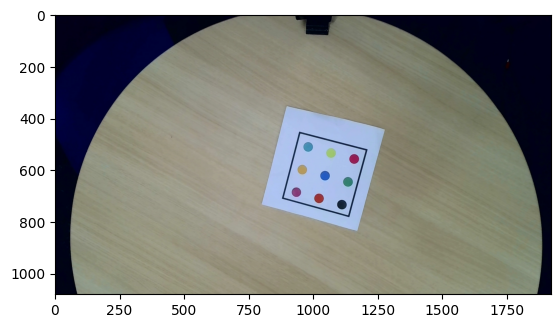

In [38]:
cal_path = "/Users/jdreiling/Desktop/puck/puck/images_calibration/high/custom/jack_cole/high_custom_jack_cole_calibration.jpg"
centers,image = findCenters(cal_path)
print(len(centers))
plt.imshow(image)

In [ ]:
def recthas(rect, dot):
        return dot in convertRectToList(rect)

def isSquare(rects):
    best = []
    for r in rects:
        # print("HEH")
        [a,b,c,d] = convertRectToList(r)
        vec_ab= np.array(a)-np.array(b)
        vec_ac = np.array(a)-np.array(c) 
        dist_ab = math.dist(a,b)
        dist_ac = math.dist(a,c)
        dot = np.dot(vec_ab, vec_ac)
        if abs(dot) < 200 and abs(dist_ab- dist_ac) < 20:
            best.append(r)
        # print(dot)
    return best
def smallBig(rectList):
    if len(rectList) > 2 or len(rectList) == 0:
        print("You have an empty list or too many rectangles, either way something is wrong")
        return 
    rect0 = rectList[0]
    rect1 = rectList[1]
    [a0,b0,_,_] = convertRectToList(rect0)
    [a1,b1,_,_] = convertRectToList(rect1)
    dist0 = math.dist(a0,b0)
    dist1 = math.dist(a1,b1)
    if dist0 > dist1:
        small = rect1
        big = rect0
    else:
        small = rect0
        big = rect1
    return (small,big)
def findSquareswBlackDot(checked_rects, black_dot):
    black_dot_rects =  [rect for rect in checked_rects if recthas(rect,black_dot)]
    squares = isSquare(black_dot_rects)
    # print(squares)
    return smallBig(isSquare(black_dot_rects))


In [105]:
black_dot_coords,color_coords = findDotColors(centers,image,25, colorspace = "cmyk")
print(color_coords)
print(black_dot_coords)

((1108, 735), [44, 254, 254])
((1020, 711), [117, 254, 254])
((932, 687), [119, 254, 254])
((1132, 647), [157, 219, 254])
((1043, 623), [132, 246, 131])
((1155, 559), [111, 254, 254])
((978, 512), [178, 220, 254])
((955, 600), [207, 254, 254])
((1066, 535), [244, 240, 254])


ValueError: min() iterable argument is empty

In [98]:
coord_list = [c[0] for c in color_coords]
rects = findRectangles(coord_list)
black_dot_rects =  [rect for rect in rects if recthas(rect,black_dot_coords[0])]
squares = isSquare(black_dot_rects)
print(len(squares))
for s in squares:
    print(s)

3
[Point(x=1043, y=623), Point(x=1020, y=711), Point(x=1132, y=647), Point(x=1108, y=735)]
[Point(x=955, y=600), Point(x=932, y=687), Point(x=1043, y=623), Point(x=1020, y=711)]
[Point(x=1066, y=535), Point(x=1043, y=623), Point(x=1155, y=559), Point(x=1132, y=647)]


In [37]:


def calibrationColors(black_dot_coords, color_coord_list):
    coord_list = [c[0] for c in color_coord_list]
    rects = findRectangles(coord_list)
    print(rects)
    small, big = findSquareswBlackDot(rects,black_dot_coords)
    small_list = convertRectToList(small)
    big_list = convertRectToList(big)
    calibration_order_list = [()] * 8
    if (black_dot_coords not in small_list) or (black_dot_coords not in big_list):
        print("Black Dot Not in at least one squares given, something is wrong!")
        return
    a = clockwisePoint(small_list, black_dot_coords)
    calibration_order_list[0] = a
    d = clockwisePoint(small_list, a)
    calibration_order_list[3] = d
    c = clockwisePoint(small_list, d)
    calibration_order_list[2] = c
    b = clockwisePoint(big_list, black_dot_coords)
    calibration_order_list[1]= b
    h = clockwisePoint(big_list, b)
    calibration_order_list[7] = h
    f = clockwisePoint(big_list, h)
    calibration_order_list[5] = f
    colored = [c for c in coord_list if c is not black_dot_coords]
    remaining = [ c for c in colored if c not in calibration_order_list]
    slope_fh = (f[1]-h[1]) / (f[0]-h[0])
    opt_1 = remaining[0]
    opt_2 = remaining[1]
    print(len(colored))
    slope_f1 = (f[1]-opt_1[1]) / (f[0]-opt_1[0])
    slope_f2 = (f[1]-opt_2[1]) / (f[0]-opt_2[0])
    print(f"abs(slope_fh - slope_f1)  {abs(slope_fh - slope_f1) }")
    print(f"abs(slope_fh - slope_f2)  {abs(slope_fh - slope_f2) }")
    if abs(slope_fh - slope_f1) < abs(slope_fh - slope_f2):
        print(f" abs(slope_fh - slope_f1) < abs(slope_fh - slope_f2) so g is ")
        calibration_order_list[6] = opt_1
        calibration_order_list[4] = opt_2
    else:
        calibration_order_list[4] = opt_1
        calibration_order_list[6] =opt_2
    calibration_order_list.insert(0,black_dot_coords)
    colored_coord_list = [c for c in color_coord_list if c[0] is not black_dot_coords]
    colors_sorted = sorted(colored_coord_list, key = lambda x: calibration_order_list.index(x[0]))
    colors = [c[1] for c in colors_sorted]
    print(colors)
    letters = (list(map(chr, range(97, 105))))
    color_dict = {}
    for i in range(len(colors)):
        color_dict.update({ tuple(colors[i]):letters[i]})
    return color_dict


calibration_colors =(calibrationColors(black_dot_coords[0],color_coords))



[[Point(x=932, y=687), Point(x=1020, y=711), Point(x=1020, y=711), Point(x=1108, y=735)], [Point(x=1043, y=623), Point(x=1020, y=711), Point(x=1132, y=647), Point(x=1108, y=735)], [Point(x=955, y=600), Point(x=1043, y=623), Point(x=1020, y=711), Point(x=1108, y=735)], [Point(x=1066, y=535), Point(x=1020, y=711), Point(x=1155, y=559), Point(x=1108, y=735)], [Point(x=955, y=600), Point(x=932, y=687), Point(x=1132, y=647), Point(x=1108, y=735)], [Point(x=1155, y=559), Point(x=1132, y=647), Point(x=1132, y=647), Point(x=1108, y=735)], [Point(x=1066, y=535), Point(x=1043, y=623), Point(x=1132, y=647), Point(x=1108, y=735)], [Point(x=932, y=687), Point(x=1043, y=623), Point(x=1020, y=711), Point(x=1132, y=647)], [Point(x=955, y=600), Point(x=932, y=687), Point(x=1043, y=623), Point(x=1020, y=711)], [Point(x=932, y=687), Point(x=1066, y=535), Point(x=1020, y=711), Point(x=1155, y=559)], [Point(x=1043, y=623), Point(x=1020, y=711), Point(x=1155, y=559), Point(x=1132, y=647)], [Point(x=1066, y=

TypeError: cannot unpack non-iterable NoneType object

In [28]:
calibration_colors

NameError: name 'calibration_colors' is not defined

In [29]:
path ="/Users/jdreiling/Desktop/puck/puck/images/custom/jack_cole/medium/D/custom_jack_cole_medium_D_1.jpg"
perm, image =(permFinder(path, block_size=25, true_colors=calibration_colors))
print(perm)

NameError: name 'calibration_colors' is not defined

In [73]:
calibration_colors

   

{(133, 198, 161): 'a',
 (138, 161, 111): 'b',
 (180, 98, 152): 'c',
 (152, 107, 55): 'd',
 (235, 143, 187): 'e',
 (130, 198, 136): 'f',
 (254, 107, 202): 'g',
 (201, 98, 106): 'h'}

In [ ]:
"#FD1622",a
"#FE00FF",b
"#00FE16",c
"#0084FE",d 
"#FEAA0D",e
"#DB4F89",f
"#EBFB26",g
"#00F8C4",h


A - '#FD1622', '#DB4F89', '#0084FE', afd
B - '#FD1622', '#00F8C4', '#00FE16',ahc
C - '#FEAA0D', '#DB4F89', '#EBFB26', ebg
D - '#DB4F89', '#DB4F89', '#DB4F89' fff


SyntaxError: invalid syntax (585755078.py, line 11)